In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

In [54]:
train_df = pd.read_csv('train.csv')
val_df = pd.read_csv('validation.csv')
test_df = pd.read_csv('test.csv')


In [ ]:
print(  train_df.shape, val_df.shape, test_df.shape)

(34189, 15) (7326, 15) (7327, 15)


In [ ]:
#Buscando informações
train_df.info()

In [ ]:
display(train_df.head())

In [55]:
# Calcular os limites para a coluna de idade ('age') no treino
q1 = train_df['age'].quantile(0.25)
q3 = train_df['age'].quantile(0.75)
iqr = q3 - q1

limite_inf = q1 - 1.5 * iqr
limite_sup = q3 + 1.5 * iqr

train_df = train_df[(train_df['age'] >= limite_inf) & (train_df['age'] <= limite_sup)]

In [56]:
mapeamento = {'<=50K': 0, '>50K': 1, '<=50K.': 0, '>50K.': 1}
y_train = train_df['income'].map(mapeamento)
y_val = val_df['income'].map(mapeamento)
y_test = test_df['income'].map(mapeamento)

X_train_bruto = train_df.drop(columns=['income'])
X_val_bruto = val_df.drop(columns=['income'])
X_test_bruto = test_df.drop(columns=['income'])

X_train_encoded = pd.get_dummies(X_train_bruto)
X_val_encoded = pd.get_dummies(X_val_bruto)
X_test_encoded = pd.get_dummies(X_test_bruto)

X_train_encoded, X_val_encoded = X_train_encoded.align(X_val_encoded, join='left', axis=1, fill_value=0)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train_encoded)
X_val_final = scaler.transform(X_val_encoded)
X_test_final = scaler.transform(X_test_encoded)


In [57]:
# Criando e treinando diretamente o algoritmo de maior performance
modelo_maximo = GradientBoostingClassifier(n_estimators=250, learning_rate=0.1, max_depth=5, random_state=42)
modelo_maximo.fit(X_train_final, y_train)

preds_val = modelo_maximo.predict(X_val_final)
f1_val = f1_score(y_val, preds_val)

tabela_resultados = pd.DataFrame({
    'Modelo': ['Gradient Boosting (Performance Máxima)'],
    'F1-Score na Validação': [f1_val]
})

display(tabela_resultados)

,Modelo,F1-Score na Validação
0,Gradient Boosting (Performance Máxima),0.723605


In [59]:
preds_finais = modelo_maximo.predict(X_test_final)
f1_final = f1_score(y_test, preds_finais)

print("RELATÓRIO FINAL DO CONJUNTO DE TESTE")
print(classification_report(y_test, preds_finais, target_names=['Ganha <=50K', 'Ganha >50K']))
print(f"🥇 Maior F1-Score Alcançado no Teste Final: {f1_final:.4f}")

RELATÓRIO FINAL DO CONJUNTO DE TESTE
              precision    recall  f1-score   support

 Ganha <=50K       0.90      0.94      0.92      5591
  Ganha >50K       0.79      0.67      0.72      1736

    accuracy                           0.88      7327
   macro avg       0.84      0.81      0.82      7327
weighted avg       0.87      0.88      0.88      7327

🥇 Maior F1-Score Alcançado no Teste Final: 0.7235


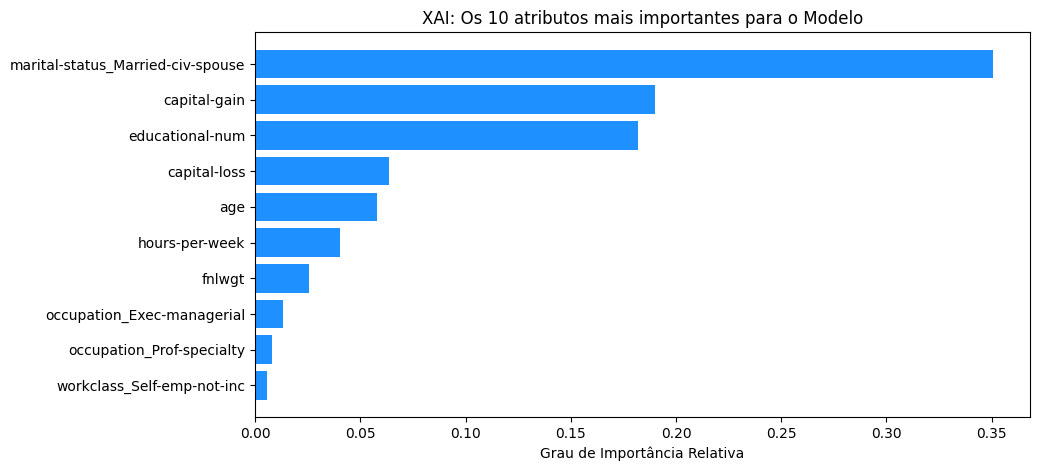

In [60]:
importancias = modelo_maximo.feature_importances_
colunas = X_train_encoded.columns

df_xai = pd.DataFrame({'Atributo': colunas, 'Importancia': importancias})
df_xai = df_xai.sort_values(by='Importancia', ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(df_xai['Atributo'], df_xai['Importancia'], color='dodgerblue')
plt.gca().invert_yaxis()
plt.title("XAI: Os 10 atributos mais importantes para o Modelo")
plt.xlabel("Grau de Importância Relativa")
plt.show()